# Problem 5 - PCA, K-Means, and Hierarchical Clustering

This notebook simulates multivariate data with an underlying cluster structure, then performs PCA,
k-means clustering, and hierarchical clustering without using the true labels during fitting.


In [1]:
### IMPORTS
# Core data and numerical libraries.
import pandas as pd
import numpy as np

# Plotting tools for PCA and clustering diagnostics.
import matplotlib.pyplot as plt
plt.style.use('default')

# Preprocessing, PCA, clustering, and recovery metrics.
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering

# Hierarchical clustering dendrogram tools.
from scipy.cluster.hierarchy import dendrogram, linkage


In [2]:
### GLOBAL VARS
# Fixed seed keeps the simulated clusters and clustering initializations reproducible.
RANDOM_SEED = 123


## Simulate Clustered Multivariate Data

The true labels are saved only for checking recovery. PCA, k-means, and hierarchical clustering are
fit using only the numeric variables.


In [3]:
def simulate_cluster_data(random_state=RANDOM_SEED):
    """Create a multivariate data set with three underlying clusters."""

    centers = np.array([
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        [3.0, 2.5, -2.0, 1.0, 2.0, -1.0],
        [-2.5, 3.0, 2.0, -2.0, 0.5, 2.5],
    ])

    X, true_labels = make_blobs(
        n_samples=[90, 80, 85],
        centers=centers,
        cluster_std=[0.85, 1.05, 1.15],
        random_state=random_state,
    )

    feature_names = [f"x{j+1}" for j in range(X.shape[1])]
    dat = pd.DataFrame(X, columns=feature_names)
    dat["true_cluster"] = true_labels

    return dat


In [4]:
# Simulate the multivariate data set and separate labels from predictors.
cluster_data = simulate_cluster_data()
feature_cols = [col for col in cluster_data.columns if col != "true_cluster"]
X = cluster_data[feature_cols].to_numpy()
true_labels = cluster_data["true_cluster"].to_numpy()

cluster_data.head()


,x1,x2,x3,x4,x5,x6,true_cluster
0,2.821769,4.224292,-0.268741,2.801242,1.753965,-2.556056,1
1,-1.221543,3.208101,3.532721,-0.862736,-0.209516,1.135080,2
2,-0.290072,-0.185254,0.597814,-0.508390,1.870597,0.585052,0
3,0.215744,0.241167,-1.200106,-1.595338,-0.866707,0.142751,0
4,-0.133193,3.423681,3.440817,-1.701967,0.855630,2.257439,2


## Standardize Variables

Standardization is important because PCA and distance-based clustering are sensitive to variable
scale. Without scaling, variables with larger units can dominate distances and principal components.


In [5]:
# Standardize each feature to mean 0 and standard deviation 1 before PCA or clustering.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

standardized_summary = pd.DataFrame(X_scaled, columns=feature_cols).agg(["mean", "std"])
standardized_summary


,x1,x2,x3,x4,x5,x6
mean,5.572884e-17,1.637035e-16,-2.351061e-17,1.584789e-16,1.863433e-16,1.184238e-16
std,1.001967e+00,1.001967e+00,1.001967e+00,1.001967e+00,1.001967e+00,1.001967e+00


## PCA Analysis


In [6]:
# Fit PCA on standardized variables.
pca = PCA()
pca_scores = pca.fit_transform(X_scaled)

# Report the proportion and cumulative proportion of variance explained.
pca_table = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "proportion_variance": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_),
})

pca_table.head(6)


,component,proportion_variance,cumulative_variance
0,PC1,0.550479,0.550479
1,PC2,0.226329,0.776808
2,PC3,0.087706,0.864513
3,PC4,0.049780,0.914294
4,PC5,0.047489,0.961783
5,PC6,0.038217,1.000000


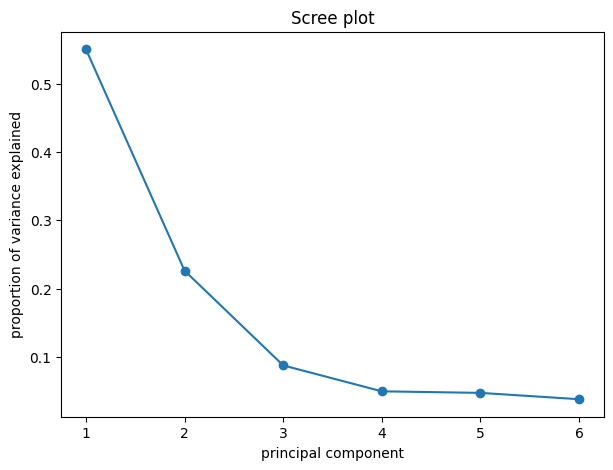

In [7]:
# Make a scree plot for the first several principal components.
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(
    np.arange(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o",
)
ax.set_title("Scree plot")
ax.set_xlabel("principal component")
ax.set_ylabel("proportion of variance explained")
ax.set_xticks(np.arange(1, len(pca.explained_variance_ratio_) + 1))
plt.show()


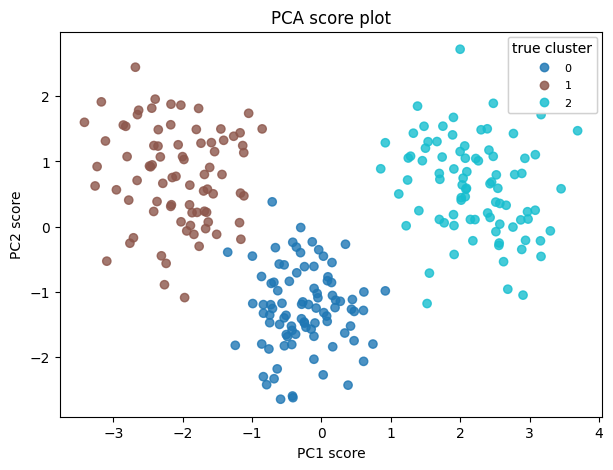

In [8]:
# Plot the first two PCA scores, coloring by true labels only for recovery checking.
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
scatter = ax.scatter(pca_scores[:, 0], pca_scores[:, 1], c=true_labels, cmap="tab10", alpha=0.80)
ax.set_title("PCA score plot")
ax.set_xlabel("PC1 score")
ax.set_ylabel("PC2 score")
legend = ax.legend(*scatter.legend_elements(), title="true cluster", fontsize=8)
ax.add_artist(legend)
plt.show()


## K-Means Clustering

K-means is run for several values of `k`. The elbow plot uses within-cluster sum of squares to look
for a point where adding more clusters has diminishing returns.


In [9]:
# Fit k-means for several candidate cluster counts.
k_values = range(1, 9)
inertias = []
kmeans_models = {}

for k in k_values:
    model = KMeans(n_clusters=k, n_init=25, random_state=RANDOM_SEED)
    model.fit(X_scaled)
    inertias.append(model.inertia_)
    kmeans_models[k] = model

elbow_table = pd.DataFrame({"k": list(k_values), "within_cluster_ss": inertias})
elbow_table


,k,within_cluster_ss
0,1,1530.000000
1,2,859.785026
2,3,536.959615
3,4,491.373230
4,5,453.796690
5,6,420.265834
6,7,397.982321
7,8,380.121332


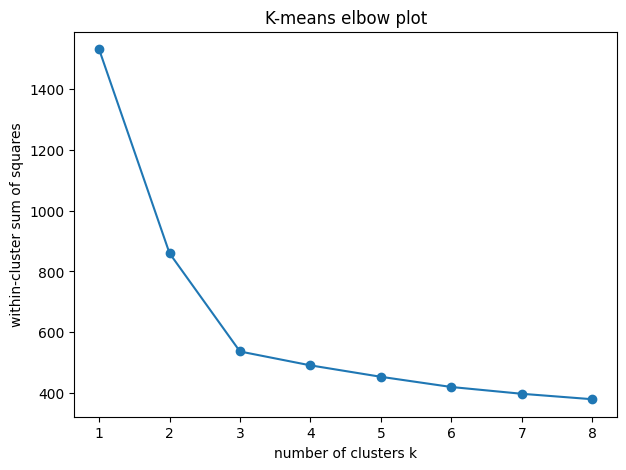

In [10]:
# Plot the k-means elbow diagnostic.
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(elbow_table["k"], elbow_table["within_cluster_ss"], marker="o")
ax.set_title("K-means elbow plot")
ax.set_xlabel("number of clusters k")
ax.set_ylabel("within-cluster sum of squares")
ax.set_xticks(list(k_values))
plt.show()


In [11]:
# Use k=3 because the simulation has three underlying clusters and the elbow should support it.
kmeans_labels = kmeans_models[3].labels_
kmeans_ari = adjusted_rand_score(true_labels, kmeans_labels)

kmeans_crosstab = pd.crosstab(
    pd.Series(true_labels, name="true_cluster"),
    pd.Series(kmeans_labels, name="kmeans_cluster"),
)

print(f"K-means adjusted Rand index: {kmeans_ari:.3f}")
kmeans_crosstab


K-means adjusted Rand index: 0.964


kmeans_cluster,0,1,2
true_cluster,,,
0,0,89,1
1,0,1,79
2,84,1,0


## Hierarchical Clustering


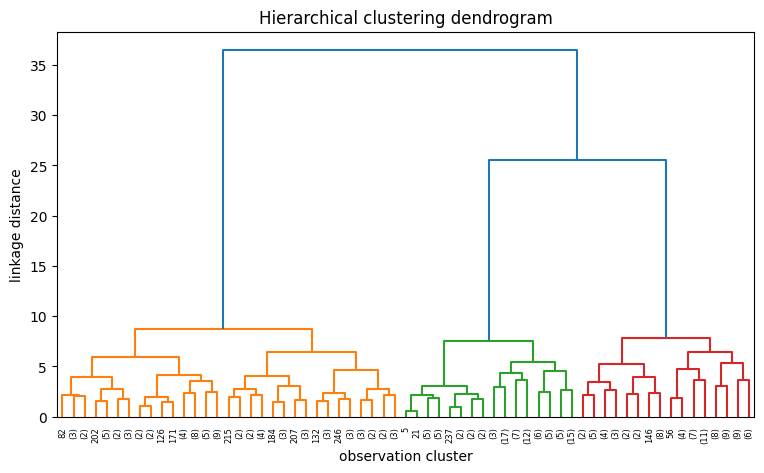

In [12]:
# Ward linkage is appropriate with Euclidean distances and compact numeric clusters.
linkage_matrix = linkage(X_scaled, method="ward")

# Display the top part of the dendrogram. Truncation keeps the plot readable.
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
dendrogram(linkage_matrix, truncate_mode="level", p=5, ax=ax)
ax.set_title("Hierarchical clustering dendrogram")
ax.set_xlabel("observation cluster")
ax.set_ylabel("linkage distance")
plt.show()


In [13]:
# Cut the hierarchical clustering tree into three clusters and compare with true labels.
hier_model = AgglomerativeClustering(n_clusters=3, linkage="ward")
hier_labels = hier_model.fit_predict(X_scaled)
hier_ari = adjusted_rand_score(true_labels, hier_labels)

hier_crosstab = pd.crosstab(
    pd.Series(true_labels, name="true_cluster"),
    pd.Series(hier_labels, name="hier_cluster"),
)

print(f"Hierarchical clustering adjusted Rand index: {hier_ari:.3f}")
hier_crosstab


Hierarchical clustering adjusted Rand index: 0.965


hier_cluster,0,1,2
true_cluster,,,
0,0,2,88
1,0,80,0
2,84,0,1


In [14]:
# Compare k-means and hierarchical labels directly.
method_comparison = pd.crosstab(
    pd.Series(kmeans_labels, name="kmeans_cluster"),
    pd.Series(hier_labels, name="hier_cluster"),
)

method_comparison


hier_cluster,0,1,2
kmeans_cluster,,,
0,84,0,0
1,0,2,89
2,0,80,0


## Interpretation

Variables should usually be standardized before PCA or clustering because both procedures depend on
variance or distance. PCA is a dimension-reduction method: it finds directions of high variance, but
it does not assign observations to groups. Clustering attempts to group observations, but it can find
patterns even when no meaningful clusters exist, so results require subject-matter caution. K-means
works best for roughly spherical, similarly sized clusters. Overlapping clusters, elongated clusters,
or clusters with very different sizes can cause k-means to split or merge groups in misleading ways.
Hierarchical clustering gives a tree of nested groupings, while k-means requires a chosen `k` and
optimizes a within-cluster sum-of-squares criterion.
